In [57]:
import reducer
from pydantic import BaseModel, Field
from typing import List
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
import operator
from dotenv import load_dotenv
load_dotenv()
class Task(BaseModel):
    id: int
    title: str
    brief: str = Field(...,description="What to cover")


In [58]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [59]:

class State(TypedDict):
    topic: str
    plan: Plan
    sections: Annotated[List[str],operator.add]
    final: str

In [60]:

llm = ChatGroq(model="llama-3.1-8b-instant")

In [61]:
from langchain_core.messages import SystemMessage, HumanMessage


def orchestrator(state: State) -> dict:
    plan = llm.with_structured_output(Plan).invoke([
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
    ])

    return {"plan": plan}


In [62]:
from langgraph.types import Send


def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [63]:

def worker(payload: dict) -> dict:

    # payload contains what we sent
    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    section_md = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    ).content.strip()

    return {"sections": [section_md]}

In [64]:

from pathlib import Path

def reducer(state:State)->dict:
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()
    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    filename = title.lower().replace(" ", "_") + ".md"
    output_path = Path(filename)
    print(output_path)
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

In [65]:
from langgraph.graph import StateGraph

g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

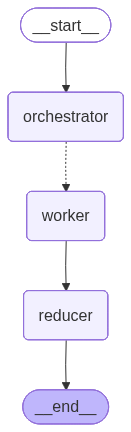

In [66]:
from langgraph.constants import START, END

g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [67]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})
print(out)

unlocking_the_power_of_self-attention:_a_deep_dive.md
{'topic': 'Write a blog on Self Attention', 'plan': Plan(blog_title='Unlocking the Power of Self-Attention: A Deep Dive', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Define self-attention, its importance, and its applications'), Task(id=2, title='History of Self-Attention', brief='Discuss the origins of self-attention, from its early beginnings to its modern use in NLP'), Task(id=3, title='How Self-Attention Works', brief='Explain the math behind self-attention, including the dot product, weights, and softmax'), Task(id=4, title='Types of Self-Attention', brief='Explore the different types of self-attention, including dot-product, additive, and multiplicative attention'), Task(id=5, title='Applications of Self-Attention', brief='Discuss how self-attention is used in NLP, computer vision, and other fields'), Task(id=6, title='Challenges and Limitations of Self-Attention', brief='Examine the challenges and limitat